# The Gamma function $\Gamma(z)$ -- the factorial, continued
### verified with SymPy, sampled with Torch, tabled with Pandas

Factorials only count whole things: $5!=120$. The **Gamma function** fills in the gaps,
$$\Gamma(z)=\int_0^\infty t^{\,z-1}e^{-t}\,dt,\qquad \Gamma(n)=(n-1)!,$$
a smooth curve through the factorial points, defined everywhere except the non-positive integers
(where it blows up). Driving `dgs/gamma_function.py`, this notebook shows:

1. how $\Gamma$ **interpolates the factorials** and where its poles are;
2. its **identities** (recurrence, reflection, duplication) checked in SymPy;
3. a lovely **Torch** estimator: $\Gamma(z)=\mathbb{E}_{T\sim\mathrm{Exp}(1)}[T^{z-1}]$, so drawing
   exponential samples *measures* the Gamma function;
4. the physics it hides in -- the **$n$-ball volume** (which famously peaks at $n=5$) and the
   **Gaussian moments** behind Maxwell-Boltzmann;
5. **Stirling's** approximation closing in on it.

Runs on the Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
import math, sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import gamma_function as gf
sp.init_printing()
print("our Gamma(5) =", gf.gamma(5), " (=4! =", 24, ")   Gamma(1/2) =", gf.gamma(0.5))

our Gamma(5) = 23.999999999999996  (=4! = 24 )   Gamma(1/2) = 1.7724538509055159


## 1. A smooth curve through the factorials

$\Gamma(n)=(n-1)!$ pins the integer points; between them it's a smooth interpolation, with a gentle
minimum near $x\approx1.4616$ ($\Gamma\approx0.8856$) and **poles at $0,-1,-2,\dots$** where the
factorial "wants to divide by zero".

Gamma(1/2) = sqrt(pi)  Gamma(7) = 720 = 6! = 720


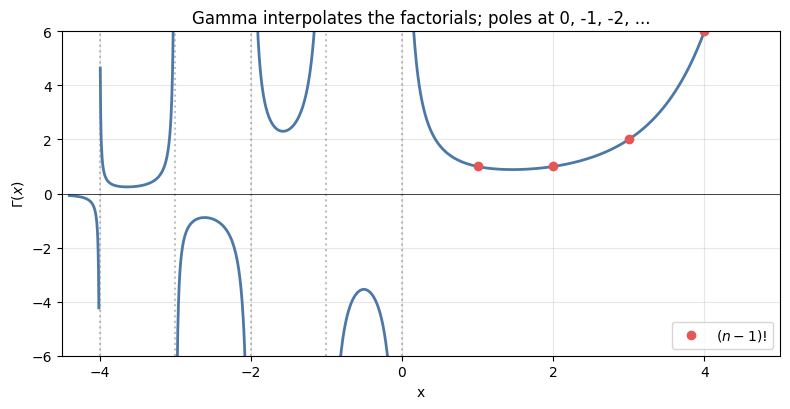

In [2]:
z = sp.symbols('z')
# SymPy pins the anchor values
assert sp.gamma(5) == 24 and sp.gamma(sp.Rational(1,2)) == sp.sqrt(sp.pi)
for n in range(1, 7):
    assert float(sp.gamma(n)) == math.factorial(n-1)
print("Gamma(1/2) =", sp.gamma(sp.Rational(1,2)), " Gamma(7) =", sp.gamma(7), "= 6! =", 720)

xs = np.linspace(-4.4, 5.0, 2000)
g = np.array([gf.gamma(x) if abs(x-round(x)) > 1e-3 or x > 0.5 else np.nan for x in xs])
g[np.abs(g) > 8] = np.nan
plt.figure(figsize=(8, 4.2))
plt.plot(xs, g, color="#4C78A8", lw=2)
plt.plot(range(1,6), [math.factorial(n-1) for n in range(1,6)], "o",
         color="#E45756", label="$(n-1)!$")
for p in range(0, -5, -1):
    plt.axvline(p, color="gray", ls=":", alpha=0.5)
plt.axhline(0, color="k", lw=0.5); plt.ylim(-6, 6); plt.xlim(-4.5, 5)
plt.xlabel("x"); plt.ylabel(r"$\Gamma(x)$")
plt.title("Gamma interpolates the factorials; poles at 0, -1, -2, ...")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. The identities (SymPy)

Three functional equations do all the work: the **recurrence** $\Gamma(z+1)=z\,\Gamma(z)$ (the source
of $(n-1)!$), the **reflection** $\Gamma(z)\Gamma(1-z)=\pi/\sin(\pi z)$, and the **Legendre
duplication** $\Gamma(z)\Gamma(z+\tfrac12)=2^{1-2z}\sqrt\pi\,\Gamma(2z)$. SymPy confirms each.

In [3]:
# recurrence, symbolically
assert sp.simplify(sp.gamma(z+1) - z*sp.gamma(z)) == 0
# reflection and duplication (SymPy's gammasimp knows them); verify numerically at sample points too
refl = sp.gammasimp(sp.gamma(z)*sp.gamma(1-z))
print("reflection: Gamma(z)Gamma(1-z) =", refl)
for zz in (0.2, 0.5, 0.8, 1.3):
    assert abs(gf.gamma(zz)*gf.gamma(1-zz) - np.pi/np.sin(np.pi*zz)) < 1e-9
    lhs = gf.gamma(zz)*gf.gamma(zz+0.5)
    rhs = 2.0**(1-2*zz)*np.sqrt(np.pi)*gf.gamma(2*zz)
    assert abs(lhs - rhs) < 1e-9
print("recurrence, reflection, duplication all verified.")

reflection: Gamma(z)Gamma(1-z) = pi/sin(pi*z)
recurrence, reflection, duplication all verified.


## 3. The integral definition, sampled by Torch

$\Gamma(z)=\int_0^\infty t^{z-1}e^{-t}\,dt$ is an **expectation** in disguise: since $e^{-t}$ is the
$\mathrm{Exp}(1)$ density, $\Gamma(z)=\mathbb{E}_{T\sim\mathrm{Exp}(1)}[T^{z-1}]$. So we can *measure*
$\Gamma$ by drawing exponential samples in Torch and averaging $T^{z-1}$ -- a Monte-Carlo Gamma
function that converges on the exact curve.

In [4]:
torch.manual_seed(0)
N = 5_000_000
T = -torch.log(torch.rand(N))                       # Exp(1) samples
zs = np.array([0.5, 1.0, 2.5, 3.7, 5.0])
mc  = [float((T**(zz-1)).mean()) for zz in zs]
ours = [gf.gamma(zz) for zz in zs]
for zz, m, o in zip(zs, mc, ours):
    print(f"z={zz:4.1f}   torch MC {m:8.4f}   exact {o:8.4f}")

# SymPy does the integral symbolically for a concrete z (2.5 -> Gamma(5/2))
tt = sp.symbols('t', positive=True)
I = sp.integrate(tt**(sp.Rational(5,2)-1)*sp.exp(-tt), (tt, 0, sp.oo))
assert sp.simplify(I - sp.gamma(sp.Rational(5,2))) == 0
print("\nSymPy: int_0^inf t^(3/2) e^-t dt =", I, "= Gamma(5/2)")

z= 0.5   torch MC   1.7716   exact   1.7725
z= 1.0   torch MC   1.0000   exact   1.0000
z= 2.5   torch MC   1.3297   exact   1.3293
z= 3.7   torch MC   4.1743   exact   4.1707
z= 5.0   torch MC  24.0152   exact  24.0000

SymPy: int_0^inf t^(3/2) e^-t dt = 3*sqrt(pi)/4 = Gamma(5/2)


## 4. Four ways to the same number (Pandas)

Our from-scratch Lanczos `gamma`, SymPy's exact value, Torch's `lgamma`, and the Torch Monte-Carlo --
all agree.

In [5]:
rows = []
for zz in zs:
    exact = float(sp.gamma(sp.nsimplify(zz)))
    tlg = float(torch.exp(torch.lgamma(torch.tensor(zz, dtype=torch.float64))))
    m = float((T**(zz-1)).mean())
    rows.append({"z": zz, "dgs Lanczos": round(gf.gamma(zz), 6), "sympy exact": round(exact, 6),
                 "torch lgamma": round(tlg, 6), "torch MC": round(m, 4),
                 "agree": abs(gf.gamma(zz)-exact) < 1e-9 and abs(tlg-exact) < 1e-9})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["agree"].all()

  z  dgs Lanczos  sympy exact  torch lgamma  torch MC  agree
0.5     1.772454     1.772454      1.772454    1.7716   True
1.0     1.000000     1.000000      1.000000    1.0000   True
2.5     1.329340     1.329340      1.329340    1.3297   True
3.7     4.170652     4.170652      4.170652    4.1743   True
5.0    24.000000    24.000000     24.000000   24.0152   True


## 5. The physics: the $n$-ball volume peaks at $n=5$

The volume of a unit ball in $n$ dimensions is $V_n=\pi^{n/2}/\Gamma(n/2+1)$ -- pure Gamma. Plot it
against dimension and something surprising happens: it **rises to a maximum at $n=5$** and then falls
to **zero** as $n\to\infty$. High-dimensional balls are almost all "corner", almost no "middle" -- a
fact that haunts statistical mechanics and machine learning alike.

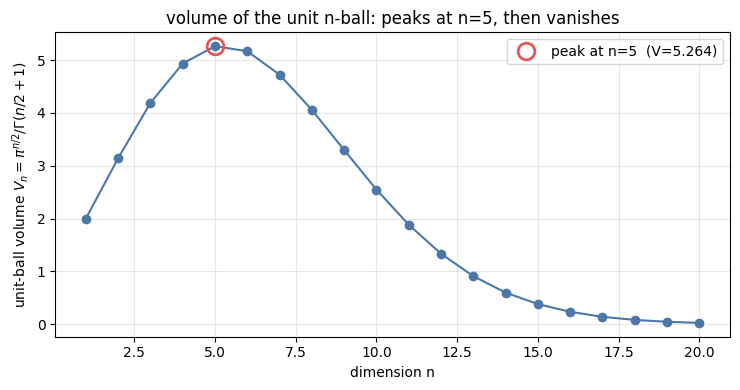

V_2 = 3.1416 (pi)   V_3 = 4.1888 (4pi/3)   argmax dimension = 5


In [6]:
ns = np.arange(1, 21)
Vn = np.array([gf.n_ball_volume(int(n), 1.0) for n in ns])
peak = ns[np.argmax(Vn)]
plt.figure(figsize=(7.5, 4))
plt.plot(ns, Vn, "o-", color="#4C78A8")
plt.plot(peak, Vn.max(), "o", ms=12, mfc="none", mec="#E45756", mew=2,
         label=f"peak at n={peak}  (V={Vn.max():.3f})")
plt.xlabel("dimension n"); plt.ylabel(r"unit-ball volume $V_n=\pi^{n/2}/\Gamma(n/2+1)$")
plt.title("volume of the unit n-ball: peaks at n=5, then vanishes")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("V_2 =", round(gf.n_ball_volume(2),4), "(pi)   V_3 =", round(gf.n_ball_volume(3),4),
      "(4pi/3)   argmax dimension =", peak)

## 6. Gaussian moments -> Maxwell-Boltzmann

Every moment of a Gaussian is a Gamma value: $\int_0^\infty x^n e^{-x^2}dx=\tfrac12\Gamma(\tfrac{n+1}{2})$.
These are exactly the integrals behind Maxwell-Boltzmann speed averages (mean speed, rms speed,...).
A Torch numerical integration matches $\tfrac12\Gamma(\tfrac{n+1}{2})$ term for term.

In [7]:
xg = torch.linspace(0, 12, 20000, dtype=torch.float64)
rows = []
for n in range(0, 6):
    num = float(torch.trapezoid((xg**n)*torch.exp(-xg**2), xg))
    exact = gf.gaussian_moment(n)
    rows.append({"n": n, "torch integral": round(num, 6),
                 "1/2 Gamma((n+1)/2)": round(exact, 6), "match": abs(num-exact) < 1e-5})
dfm = pd.DataFrame(rows)
print(dfm.to_string(index=False))
assert dfm["match"].all()
print("\nn=0 -> sqrt(pi)/2 (normalization);  n=2 -> sqrt(pi)/4 (relates to <v^2>, rms speed).")

 n  torch integral  1/2 Gamma((n+1)/2)  match
 0        0.886227            0.886227   True
 1        0.500000            0.500000   True
 2        0.443113            0.443113   True
 3        0.500000            0.500000   True
 4        0.664670            0.664670   True
 5        1.000000            1.000000   True

n=0 -> sqrt(pi)/2 (normalization);  n=2 -> sqrt(pi)/4 (relates to <v^2>, rms speed).


## 7. Stirling closes in

$\Gamma(z)\sim\sqrt{2\pi/z}\,(z/e)^z$ -- the approximation behind $\ln N!\approx N\ln N-N$ in every
entropy calculation. Its relative error falls off like $1/z$.

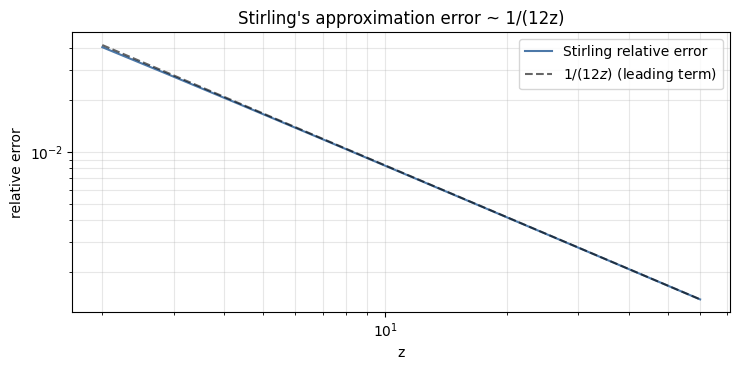

Gamma(50)/stirling(50) = 1.001668  -> 1


In [8]:
zz = np.linspace(2, 60, 200)
rel_err = np.array([abs(gf.gamma(v) - gf.stirling(v))/gf.gamma(v) for v in zz])
plt.figure(figsize=(7.5, 3.8))
plt.loglog(zz, rel_err, color="#4C78A8", label="Stirling relative error")
plt.loglog(zz, 1/(12*zz), "k--", alpha=0.6, label=r"$1/(12z)$ (leading term)")
plt.xlabel("z"); plt.ylabel("relative error"); plt.legend()
plt.title("Stirling's approximation error ~ 1/(12z)"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("Gamma(50)/stirling(50) =", round(gf.gamma(50)/gf.stirling(50), 6), " -> 1")

## What we did

* Saw $\Gamma$ as the **smooth factorial**, with poles at the non-positive integers.
* Verified its **recurrence, reflection, and duplication** identities in SymPy.
* **Measured** it with Torch via $\Gamma(z)=\mathbb{E}_{\mathrm{Exp}(1)}[T^{z-1}]$ and agreed four
  independent ways (Lanczos / SymPy / `torch.lgamma` / Monte-Carlo) in a Pandas table.
* Watched it drive the **$n$-ball volume** (peak at $n=5$, then $\to0$) and the **Gaussian moments**
  of Maxwell-Boltzmann, and saw **Stirling** converge.

`dgs/gamma_function.py` is the tested primitive; the *physics* gammas (Lorentz factor, $C_p/C_v$,
decay rate, reflection coefficient) live in their own modules -- this is the function that quietly
normalizes them all.